# Pade approximation for FRB DM cosmic

### Packages & Constants

In this section, we are loading the basic modules of interest, and define our constants and basic functions.

In [1]:
### Arrays, vectorisation & special functions ###
import numpy as np
from scipy.integrate import quad
import scipy.constants as const

from numpy.random import default_rng
rng = default_rng(seed=1)

### Plots and Styling ###
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm, ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

font = 'sans-serif'
font_size = 13
rcParams['font.family'] = font
rcParams['font.size']= font_size

### Astropy Package - for cosmological calculations ###
import astropy.units as u
from astropy.cosmology import z_at_value
from astropy.cosmology import FlatLambdaCDM

__Useful constants__

In [2]:
f_IGM = 0.84
OMEGA_BARYONS = 0.04897
PI = const.pi
C_LIGHT = const.c
G_NEWTON = const.G
M_PROTON = const.m_p

##########################
### Define cosmo model ###
##########################

# We assume a flat, FRW universe.
OMEGA_MATTER = 0.30966 
HUBBLE = 67.66
cosmo_model = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER)

## Basic definitions <a name="Definitions"></a>

We are defining the **luminosity distance**, observed through GWs:

$$
d_L = (1+z) \frac{c}{H_0} \int_0^z \frac{dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)}} = d^0_L \cdot (1+z) \cdot f(z).
$$

We are defining the diffuse **dispersion measure (DM)**, based on [[Deng & Zhang, 2014](https://iopscience.iop.org/article/10.1088/2041-8205/783/2/L35/pdf)], eq. (13) and eq. (12) of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)], for a flat $\Lambda$CDM:

$$
{\rm DM}_{\rm diff} = \frac{3 c H_0 \Omega_b f_{\rm IGM}}{8 \pi G m_p} \chi_{7/8} \int_0^z \frac{ (1+z) dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)}} = {\rm DM}_{\rm diff}^0 \cdot g(z).
$$


Assuming redshifts $z<2$, we use $\chi_{7/8} \simeq 7/8$ - this assumes that the Universe is fully ionised at that time.

In [3]:
# Define the two integrands - we will use them for numerical integration

def dL_integrand(z, Om):
    """
    Function that it inside the integral of the DL formula.
    
    Input
    ----------
    z : redshift
    Om: Omega matter
    """
    return 1/np.sqrt(Om*(1+z)**3+1-Om)


def dDM_integrand(z, Om):
    """
    Function that it inside the integral of the DM formula.
    
    Input
    ----------
    z : redshift
    Om: Omega matter
    """
    return (1+z)/(np.sqrt(Om*(1+z)**3+1-Om))

In [4]:
########################################################
### Functions to calculate the integrals numerically ###
########################################################

def DL_distance(z, Om):
    """
    Calculates the integral in the DL formulae,
    for a given pair of (z, Om).
    
    Input
    ----------
    z : `float`
        redshift
    Om : Omega_matter
    
    Returns
    ----------
    integral : `float`
        integral value for (z, Om) pair for DL distance
    """

    integral = quad(dL_integrand, 0, z, args=(Om))[0]
    
    return (1+z)*integral


def DM_distance(z, Om):
    """
    Calculates the integral in the DM formulae,
    for a given pair of (z, Om).
    
    Input
    ----------
    z : `float`
        redshift
    Om : Omega_matter
    
    Returns
    ----------
    integral : `float`
        integral value for (z, Om) pair for DM distance
    """
    integral = quad(dDM_integrand, 0, z, args=(Om))[0]
    
    return integral

In [5]:
# We integrate between z = [0, 2]
redshifts = np.linspace(0.01, 2.0, 200)

# Compare our luminosity distance integral with the result for AstroPy.

# Note: we need to multiply the AstroPy result with Ho/c,
# to make the units consistent for the comparison (Astropy uses km/s).

dL_astropy = (HUBBLE/(C_LIGHT/1e3))*cosmo_model.luminosity_distance(redshifts).value

We calculate the integrals for a:

- Flat, LCDM universe ($\Omega_m = 0.30966, \Omega_\Lambda = 1-\Omega_m$)
- Flat, MD universe ($\Omega_m = 1.0, \Omega_\Lambda = 1-\Omega_m$)
- Flat, LD universe ($\Omega_m \rightarrow 0.0, \Omega_\Lambda = 1-\Omega_m$)

In [42]:
DM_LCDM_array = np.zeros_like(redshifts)
DL_LCDM_array = np.zeros_like(redshifts)
DM_MD_array = np.zeros_like(redshifts)
DL_MD_array = np.zeros_like(redshifts)
DM_LD_array = np.zeros_like(redshifts)
DL_LD_array = np.zeros_like(redshifts)


DM_lowOm_array = np.zeros_like(redshifts)

for i , z in enumerate(redshifts):
    DM_LCDM_array[i] = DM_distance(z, Om=OMEGA_MATTER)
    DL_LCDM_array[i] = DL_distance(z, Om=OMEGA_MATTER)
    DM_MD_array[i] = DM_distance(z, Om=1.0)
    DL_MD_array[i] = DL_distance(z, Om=1.0)
    DM_LD_array[i] = DM_distance(z, Om=0.01)
    DL_LD_array[i] = DL_distance(z, Om=0.01)
    DM_lowOm_array[i] = DM_distance(z, Om=0.2)

### Comparison with AstroPy

Comparing the `scipy` integraton with `AstroPy` results, in the LCDM case. The results seem consistent in very good \% agreement.

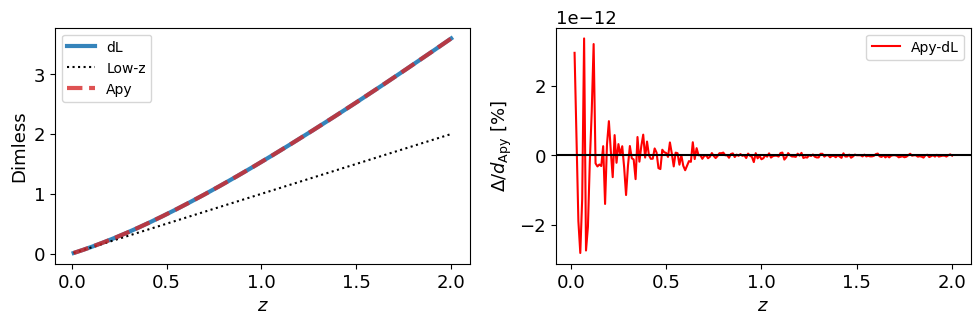

In [9]:
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)

ax1.plot(redshifts, DL_LCDM_array, label='dL', c='tab:blue', lw=3, alpha=0.9)
ax1.plot(redshifts, redshifts, label='Low-z', ls=':', c='black')
ax1.plot(redshifts, dL_astropy, label='Apy', ls='--', c='tab:red', lw=3, alpha=0.8)
ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'Dimless')
ax1.legend(fontsize=10)

ax2.plot(redshifts[1:], (dL_astropy[1:]-DL_LCDM_array[1:])/dL_astropy[1:]*100, label='Apy-dL', c='red')
ax2.axhline(y=0, c='black')
ax2.set_xlabel(r'$z$')
ax2.set_ylabel(r'$\Delta/d_{\rm Apy}$ [$\%$]')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Integrands comparison

Comparing just the integrands (i.e. we have removed any constants or astrophysical factors).

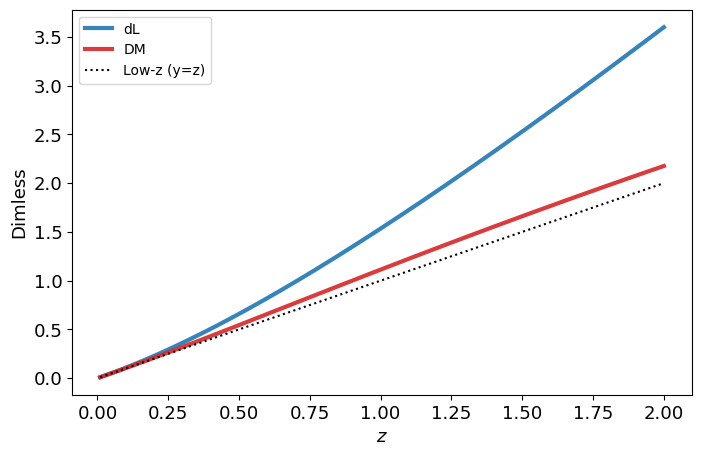

In [8]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.plot(redshifts, DL_LCDM_array, label='dL', c='tab:blue', lw=3, alpha=0.9)
ax1.plot(redshifts, DM_LCDM_array, label='DM', c='tab:red', lw=3, alpha=0.9)
ax1.plot(redshifts, redshifts, label='Low-z (y=z)', ls=':', c='black')
ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'Dimless')
ax1.legend(fontsize=10)

plt.show()

### Investigating timing

__Timing__

In [42]:
import timeit

In [43]:
## z=0.5

print("\n Timing for DL -- astropy --:")
%timeit (HUBBLE/(C_LIGHT/1e3))*cosmo_model.luminosity_distance(0.5).value

print("\n Timing for DL -- quad --:")
%timeit DL_distance(0.5, Om=OMEGA_MATTER)

print("\n Timing for DM -- quad --:")
%timeit  DM_distance(z, Om=OMEGA_MATTER)


 Timing for DL -- astropy --:
77.5 μs ± 4.56 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

 Timing for DL -- quad --:
48.7 μs ± 4.03 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

 Timing for DM -- quad --:
46.6 μs ± 4.17 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### Distance Approximants  [**MK: To Update this section**]

To avoid costly integrations, it is possible to develop approximations for the different distances. The main idea behind these, is a series approximation of the integral, and then different "tricks" to retain good behaviour at all redshifts.

For all the distances we calculate the dimensionless values, i.e. ignoring any astrophysical/cosmological parameters which are just multiplying factors. The approximants for the luminosity distance are taken from [here](https://arxiv.org/pdf/1111.6396.pdf) and [here](https://arxiv.org/pdf/1003.0483.pdf).

A detailed derivation of the _Pade approximants_ can be found in the Appendix (at the end of the notebook).

In [10]:
########################################
### Luminosity Distance Approximants ###
########################################


#######################################
### Adachi-Kasai (pade) approximant ###
#######################################

def Phi(x):
    b1 = 4222975319/1599088274
    b2 = 1138125153117/1288865148844
    b3 = 7433983569773/139933930445920
    c1 = 635916643/456882364
    c2 = 14505955555/28326706568
    c3 = 44686179629/1133068262720
    
    return (2.0+b1*x+b2*x**2+b3*x**3)/(1.0+c1*x+c2*x**2+c3*x**3)
        
def x_phi(z, Om):
    return (1.-Om)/Om/(1.+z)**3
    
def dL_pade(z, Om):
    x0 = x_phi(0, Om)
    x = x_phi(z, Om)
    factor = (1.+z)/Om**(1/2)
    
    return factor*(Phi(x0)-Phi(x)/(1.+z)**(1/2))

In [34]:
###############################
### DM Distance Approximants ###
###############################

###########################
### DM Pade approximant ###
###########################

def PhiDM(x):
    b1 = -2.85592665
    b2 = -1.0945641
    b3 = -0.0913347
    c1 = 1.32796333
    c2 = 0.44857662
    c3 = 0.02769881
    
    return (-2.0+b1*x+b2*x**2+b3*x**3)/(1.0+c1*x+c2*x**2+c3*x**3)
        
def x_phiDM(z, Om):
    return (1.-Om)/Om/(1.+z)**3
    
def DM_pade(z, Om):
    x0 = x_phiDM(0, Om)
    x = x_phiDM(z, Om)
    factor = 1.0/Om**(1/2)
    
    return factor*(PhiDM(x0)-PhiDM(x)*(1.+z)**(1/2))

__Approximant distance checks__

We check how well the approximate distance measures perform in terms of accuracy and timing. Note that these are _cosmology dependent_ (we comment on this at the end).

$dL$ distance checks (accuracy)

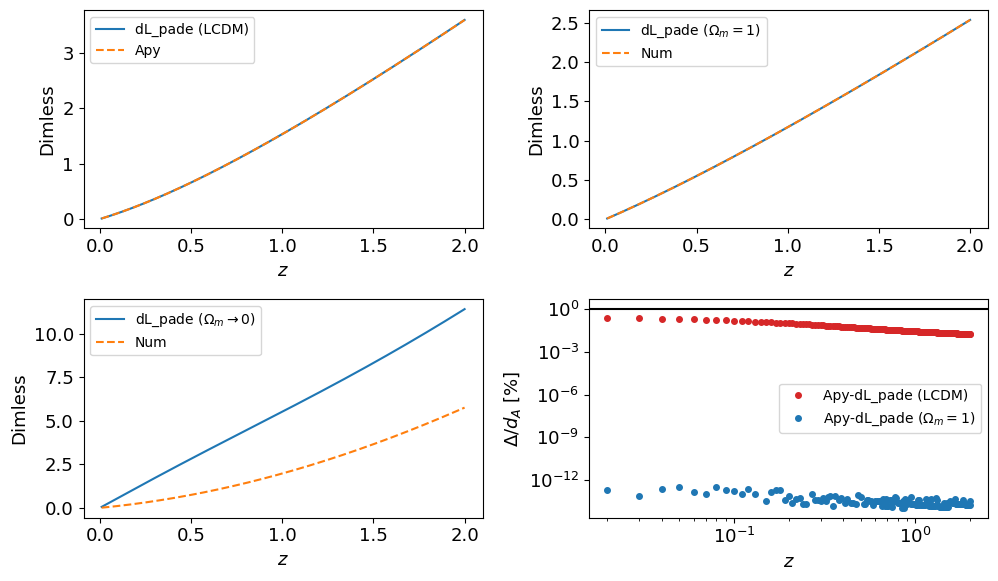

In [21]:
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)


ax1.plot(redshifts, dL_pade(redshifts, OMEGA_MATTER), label='dL_pade (LCDM)')
ax1.plot(redshifts, dL_astropy, label='Apy', ls='--')
ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'Dimless')
ax1.legend(fontsize=10)

ax2.plot(redshifts, dL_pade(redshifts, Om=1), label=r'dL_pade ($\Omega_m=1$)')
ax2.plot(redshifts, DL_MD_array, label='Num', ls='--')
ax2.set_xlabel(r'$z$')
ax2.set_ylabel(r'Dimless')
ax2.legend(fontsize=10)

ax3.plot(redshifts, dL_pade(redshifts, Om=0.01), label=r'dL_pade ($\Omega_m \rightarrow 0$)')
ax3.plot(redshifts, DL_LD_array, label='Num', ls='--')
ax3.set_xlabel(r'$z$')
ax3.set_ylabel(r'Dimless')
ax3.legend(fontsize=10)

ax4.plot(redshifts[1:], np.abs((dL_astropy[1:]-dL_pade(redshifts[1:], OMEGA_MATTER)))/(dL_astropy[1:])*100,\
         label='Apy-dL_pade (LCDM)', c='tab:red', marker ='o', markersize=4, ls='')
ax4.plot(redshifts[1:], np.abs((DL_MD_array[1:]-dL_pade(redshifts[1:], Om=1)))/(DL_MD_array[1:])*100,\
         label=r'Apy-dL_pade ($\Omega_m=1$)', c='tab:blue', marker ='o', markersize=4, ls='')

ax4.axhline(y=1, c='black')
ax4.set_xlabel(r'$z$')
ax4.set_ylabel(r'$\Delta/d_A$ [$\%$]')
ax4.set_yscale('log')
ax4.set_xscale('log')
#ax2.set_ylim(10e-3, 0.3)
ax4.legend(fontsize=10)

plt.tight_layout()
plt.show()

${\rm DM}$ dispersion measure checks (accuracy)

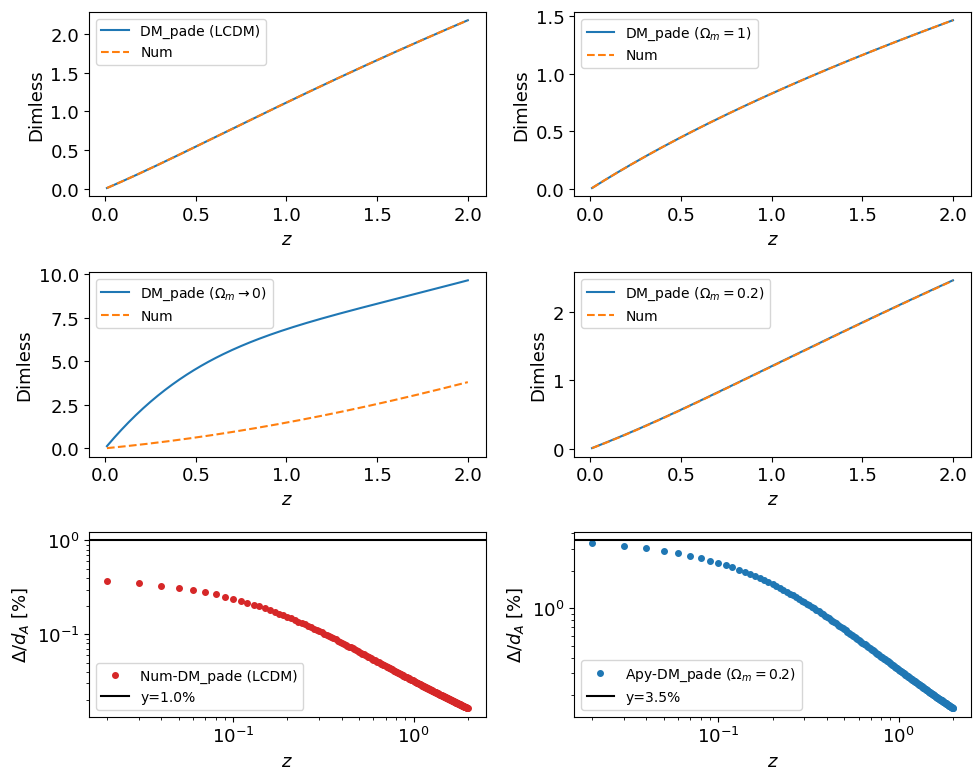

In [53]:
fig = plt.figure(figsize=(10,8))
ax1 = fig.add_subplot(3, 2, 1)
ax2 = fig.add_subplot(3, 2, 2)
ax3 = fig.add_subplot(3, 2, 3)
ax4 = fig.add_subplot(3, 2, 4)
ax5 = fig.add_subplot(3, 2, 5)
ax6 = fig.add_subplot(3, 2, 6)


ax1.plot(redshifts, DM_pade(redshifts, OMEGA_MATTER), label='DM_pade (LCDM)')
ax1.plot(redshifts, DM_LCDM_array, label='Num', ls='--')
ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'Dimless')
ax1.legend(fontsize=10)

ax2.plot(redshifts, DM_pade(redshifts, Om=1), label=r'DM_pade ($\Omega_m=1$)')
ax2.plot(redshifts, DM_MD_array, label='Num', ls='--')
ax2.set_xlabel(r'$z$')
ax2.set_ylabel(r'Dimless')
ax2.legend(fontsize=10)

ax3.plot(redshifts, DM_pade(redshifts, Om=0.01), label=r'DM_pade ($\Omega_m \rightarrow 0$)')
ax3.plot(redshifts, DM_LD_array, label='Num', ls='--')
ax3.set_xlabel(r'$z$')
ax3.set_ylabel(r'Dimless')
ax3.legend(fontsize=10)

ax4.plot(redshifts, DM_pade(redshifts, Om=0.2), label=r'DM_pade ($\Omega_m = 0.2$)')
ax4.plot(redshifts, DM_lowOm_array, label='Num', ls='--')
ax4.set_xlabel(r'$z$')
ax4.set_ylabel(r'Dimless')
ax4.legend(fontsize=10)

ax5.plot(redshifts[1:], np.abs((DM_LCDM_array[1:]-DM_pade(redshifts[1:], OMEGA_MATTER)))/(DM_LCDM_array[1:])*100,\
         label='Num-DM_pade (LCDM)', c='tab:red', marker ='o', markersize=4, ls='')
# ax5.plot(redshifts[1:], np.abs((DM_MD_array[1:]-DM_pade(redshifts[1:], Om=1)))/(DM_MD_array[1:])*100,\
#          label=r'Apy-DM_pade ($\Omega_m=1$)', c='tab:blue', marker ='o', markersize=4, ls='')
ax5.axhline(y=1, c='black', label='y=1.0%')
ax5.set_xlabel(r'$z$')
ax5.set_ylabel(r'$\Delta/d_A$ [$\%$]')
ax5.set_yscale('log')
ax5.set_xscale('log')
#ax2.set_ylim(10e-3, 0.3)
ax5.legend(fontsize=10)

ax6.plot(redshifts[1:], np.abs((DM_lowOm_array[1:]-DM_pade(redshifts[1:], Om=0.2)))/(DM_lowOm_array[1:])*100,\
         label=r'Apy-DM_pade ($\Omega_m=0.2$)', c='tab:blue', marker ='o', markersize=4, ls='')
ax6.axhline(y=3.5, c='black', label='y=3.5%')
ax6.set_xlabel(r'$z$')
ax6.set_ylabel(r'$\Delta/d_A$ [$\%$]')
ax6.set_yscale('log')
ax6.set_xscale('log')
#ax2.set_ylim(10e-3, 0.3)
ax6.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [50]:
np.max(np.abs((DM_lowOm_array[1:]-DM_pade(redshifts[1:], Om=0.2)))/(DM_lowOm_array[1:])*100)

np.float64(3.3368682527818057)

__Approximant Timing estimates__

In [33]:
def joint_DD_DL_ratio(z, Om,  z_min=0.1, z_max=1.0):
    return joint_dD(z, Om, z_min, z_max)/joint_dL(z, Om, z_min, z_max)

def DD_DL_pade_ratio(z, Om):
    return dD_pade_high_z(z, Om)/dL_pade_high_z(z, Om)

def DD_DL_ps_ratio(z, Om):
    return dD_ps_small_z(z, Om)/dL_ps_small_z(z, Om)

In [34]:
print("\n Timing for luminosity distance -- Pade, high-z --:")
%timeit dL_pade_high_z(0.5, Omega_matter)

print("\n Timing for luminosity distance -- WU appro, high-z --:")
%timeit dL_WU(0.5, Omega_matter)

print("\n Timing for luminosity distance -- Power series, small-z --:")
%timeit dL_ps_small_z(0.5, Omega_matter)

print("\n Timing for luminosity distance -- Joint distance, all-z --:")
%timeit joint_dL(0.5, Omega_matter)

########################################################################

print("\n Timing for D distance -- Pade, high-z --:")
%timeit dD_pade_high_z(0.5, Omega_matter)

print("\n Timing for D distance -- Power series, small-z --:")
%timeit dD_ps_small_z(0.5, Omega_matter)

print("\n Timing for D distance -- Joint distance, all-z --:")
%timeit joint_dD(0.5, Omega_matter)

#########################################################################

print("\n Timing for DD/DL approximant ratio -- Joint distance, all-z --:")
%timeit joint_DD_DL_ratio(0.5, Omega_matter)

print("\n Timing for DD/DL pade ratio -- Joint distance, all-z --:")
%timeit DD_DL_pade_ratio(0.5, Omega_matter)

print("\n Timing for DD/DL ps ratio -- Joint distance, all-z --:")
%timeit DD_DL_ps_ratio(0.5, Omega_matter)


 Timing for luminosity distance -- Pade, high-z --:
4.68 μs ± 133 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

 Timing for luminosity distance -- WU appro, high-z --:
13.9 μs ± 418 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

 Timing for luminosity distance -- Power series, small-z --:
2.88 μs ± 9.03 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

 Timing for luminosity distance -- Joint distance, all-z --:
2.09 ms ± 3.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

 Timing for D distance -- Pade, high-z --:
4.56 μs ± 84.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

 Timing for D distance -- Power series, small-z --:
2.68 μs ± 5.04 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

 Timing for D distance -- Joint distance, all-z --:
2.28 ms ± 8.85 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

 Timing for DD/DL approximant ratio -- Joint distance, all-z --:
4.39 ms ± 60 μs per loop (mea

## Summary

- The numerical distances are better than the approximants for many orders of magnitude (__errors $[\%]$ ~ $10^{-13}$ vs $10^{-1}$__).

- The approximant ratio is faster than the numerical one, for a little more than __an order of magnitude__ (for the Pade approximants): 
    1) For $\Omega_m \geq 0.18$, $\times\ 20$ faster, with error $< 1\%$.
    2) For $\Omega_m \geq 0.285$, $\times\ 20$ faster, with error $< 0.1\%$.
    3) For $\Omega_m \geq 0.4$, $\times\ 20$ faster, with error $< 0.01\%$.
\
&nbsp;

- For sampling $\Omega_m$ values below 0.1, the errors in the ratio reach $10\%$, if using the Pade approximants (for low-$z$). 

--------------------------------------------------------------

## Appendix - Distance Approximants details

Here we calculate the Pade approximants for the luminosity distance $d_L$ and the dispersion measure ${\rm DM}$, following [[1111.6396](https://arxiv.org/abs/1111.6396)]. For more details, see [Bender & Orszag, Chapter 8.3].

The main steps are the following:

1. Change of variables $z \rightarrow a=1/(1+z)$. So for large $z$, $a$ will go to zero.
2. For $a \rightarrow 0$, we expand the integrand as a power series.
3. We integrate the power series, so we have a polynomial that we truncate to a desired value of $\mathcal{O}(a^n)$ (since $a$ is small).
4. We approximate this power series with a *Pade Approximant*.

In [49]:
from sympy import *
from scipy.interpolate import pade

In [52]:
## These are the already transformed variables

x, a, om = symbols('x a \Omega_m')

### Luminosity distance $dL$

- Step 1: Change of variables and specify the integrand

In [53]:
# Defining the helpful function
Fa = integrate(sqrt(om)/sqrt(om*x+(1-om)*x**4), (x, 0, a))
Fa

sqrt(\Omega_m)*Integral(1/sqrt(-\Omega_m*x**4 + \Omega_m*x + x**4), (x, 0, a))

- Steps 2 & 3: Expand the integrand to a power series and integrate

In [55]:
Fa_series = Fa.series(a, 0, 20)
Fa_series

2*sqrt(a) + a**(7/2)*(1/7 - 1/(7*\Omega_m)) + a**(13/2)*(3/52 - 3/(26*\Omega_m) + 3/(52*\Omega_m**2)) + a**(19/2)*(5/152 - 15/(152*\Omega_m) + 15/(152*\Omega_m**2) - 5/(152*\Omega_m**3)) + a**(25/2)*(7/320 - 7/(80*\Omega_m) + 21/(160*\Omega_m**2) - 7/(80*\Omega_m**3) + 7/(320*\Omega_m**4)) + a**(31/2)*(63/3968 - 315/(3968*\Omega_m) + 315/(1984*\Omega_m**2) - 315/(1984*\Omega_m**3) + 315/(3968*\Omega_m**4) - 63/(3968*\Omega_m**5)) + a**(37/2)*(231/18944 - 693/(9472*\Omega_m) + 3465/(18944*\Omega_m**2) - 1155/(4736*\Omega_m**3) + 3465/(18944*\Omega_m**4) - 693/(9472*\Omega_m**5) + 231/(18944*\Omega_m**6)) + O(a**20)

Making the powers clearer, by factorising $\sqrt{a}$.

In [56]:
Fa_series = expand(Fa_series/sqrt(a))
Fa_series

231*a**18/(18944*\Omega_m**6) - 63*a**15/(3968*\Omega_m**5) - 693*a**18/(9472*\Omega_m**5) + 7*a**12/(320*\Omega_m**4) + 315*a**15/(3968*\Omega_m**4) + 3465*a**18/(18944*\Omega_m**4) - 5*a**9/(152*\Omega_m**3) - 7*a**12/(80*\Omega_m**3) - 315*a**15/(1984*\Omega_m**3) - 1155*a**18/(4736*\Omega_m**3) + 3*a**6/(52*\Omega_m**2) + 15*a**9/(152*\Omega_m**2) + 21*a**12/(160*\Omega_m**2) + 315*a**15/(1984*\Omega_m**2) + 3465*a**18/(18944*\Omega_m**2) - a**3/(7*\Omega_m) - 3*a**6/(26*\Omega_m) - 15*a**9/(152*\Omega_m) - 7*a**12/(80*\Omega_m) - 315*a**15/(3968*\Omega_m) - 693*a**18/(9472*\Omega_m) + 2 + a**3/7 + 3*a**6/52 + 5*a**9/152 + 7*a**12/320 + 63*a**15/3968 + 231*a**18/18944 + O(a**(39/2))

Collecting all the powers of $a$ together.

In [57]:
Fa_series = collect(Fa_series, a).removeO()
Fa_series

a**18*(231/18944 - 693/(9472*\Omega_m) + 3465/(18944*\Omega_m**2) - 1155/(4736*\Omega_m**3) + 3465/(18944*\Omega_m**4) - 693/(9472*\Omega_m**5) + 231/(18944*\Omega_m**6)) + a**15*(63/3968 - 315/(3968*\Omega_m) + 315/(1984*\Omega_m**2) - 315/(1984*\Omega_m**3) + 315/(3968*\Omega_m**4) - 63/(3968*\Omega_m**5)) + a**12*(7/320 - 7/(80*\Omega_m) + 21/(160*\Omega_m**2) - 7/(80*\Omega_m**3) + 7/(320*\Omega_m**4)) + a**9*(5/152 - 15/(152*\Omega_m) + 15/(152*\Omega_m**2) - 5/(152*\Omega_m**3)) + a**6*(3/52 - 3/(26*\Omega_m) + 3/(52*\Omega_m**2)) + a**3*(1/7 - 1/(7*\Omega_m)) + 2

Substitute everywhere $x = (1-\Omega_m)/\Omega_m \times a^3$.

In [58]:
Fx_series = Fa_series.subs(a, (om/(1-om)*x)**(1/3)).removeO()
Fx_series

(\Omega_m*x/(1 - \Omega_m))**1.0*(1/7 - 1/(7*\Omega_m)) + (\Omega_m*x/(1 - \Omega_m))**2.0*(3/52 - 3/(26*\Omega_m) + 3/(52*\Omega_m**2)) + (\Omega_m*x/(1 - \Omega_m))**3.0*(5/152 - 15/(152*\Omega_m) + 15/(152*\Omega_m**2) - 5/(152*\Omega_m**3)) + (\Omega_m*x/(1 - \Omega_m))**4.0*(7/320 - 7/(80*\Omega_m) + 21/(160*\Omega_m**2) - 7/(80*\Omega_m**3) + 7/(320*\Omega_m**4)) + (\Omega_m*x/(1 - \Omega_m))**5.0*(63/3968 - 315/(3968*\Omega_m) + 315/(1984*\Omega_m**2) - 315/(1984*\Omega_m**3) + 315/(3968*\Omega_m**4) - 63/(3968*\Omega_m**5)) + (\Omega_m*x/(1 - \Omega_m))**6.0*(231/18944 - 693/(9472*\Omega_m) + 3465/(18944*\Omega_m**2) - 1155/(4736*\Omega_m**3) + 3465/(18944*\Omega_m**4) - 693/(9472*\Omega_m**5) + 231/(18944*\Omega_m**6)) + 2

In [59]:
collect(simplify(Fx_series), x)

(10153794560*\Omega_m**6 + 725271040*\Omega_m**5*(-\Omega_m*x/(\Omega_m - 1))**1.0*(\Omega_m - 1) + 292897920*\Omega_m**4*(-\Omega_m*x/(\Omega_m - 1))**2.0*(\Omega_m**2 - 2*\Omega_m + 1) + 167003200*\Omega_m**3*(-\Omega_m*x/(\Omega_m - 1))**3.0*(\Omega_m**3 - 3*\Omega_m**2 + 3*\Omega_m - 1) + 111057128*\Omega_m**2*(-\Omega_m*x/(\Omega_m - 1))**4.0*(\Omega_m**4 - 4*\Omega_m**3 + 6*\Omega_m**2 - 4*\Omega_m + 1) + 80605980*\Omega_m*(-\Omega_m*x/(\Omega_m - 1))**5.0*(\Omega_m**5 - 5*\Omega_m**4 + 10*\Omega_m**3 - 10*\Omega_m**2 + 5*\Omega_m - 1) + 61906845*(-\Omega_m*x/(\Omega_m - 1))**6.0*(\Omega_m**6 - 6*\Omega_m**5 + 15*\Omega_m**4 - 20*\Omega_m**3 + 15*\Omega_m**2 - 6*\Omega_m + 1))/(5076897280*\Omega_m**6)

In [62]:
# Cross-check the cancellations

expand((om-1)**6)

\Omega_m**6 - 6*\Omega_m**5 + 15*\Omega_m**4 - 20*\Omega_m**3 + 15*\Omega_m**2 - 6*\Omega_m + 1

In [63]:
expand((om-1)**5)

\Omega_m**5 - 5*\Omega_m**4 + 10*\Omega_m**3 - 10*\Omega_m**2 + 5*\Omega_m - 1

In [64]:
expand((om-1)**4)

\Omega_m**4 - 4*\Omega_m**3 + 6*\Omega_m**2 - 4*\Omega_m + 1

In [65]:
expand((om-1)**3)

\Omega_m**3 - 3*\Omega_m**2 + 3*\Omega_m - 1

In [66]:
# Let's find the coefficients

print("Coefficient of x^0:", 10153794560/5076897280)
print("Coefficient of x^1:", 725271040/5076897280)
print("Coefficient of x^2:", 292897920/5076897280)
print("Coefficient of x^3:", 167003200/5076897280)
print("Coefficient of x^4:", 111057128/5076897280)
print("Coefficient of x^5:", 80605980/5076897280)
print("Coefficient of x^6:", 61906845/5076897280)

Coefficient of x^0: 2.0
Coefficient of x^1: 0.14285714285714285
Coefficient of x^2: 0.057692307692307696
Coefficient of x^3: 0.03289473684210526
Coefficient of x^4: 0.021875
Coefficient of x^5: 0.015877016129032258
Coefficient of x^6: 0.012193834459459459


- Step 4: Turn the power series to a Pade Approximant

In [67]:
## Power series coefficients
F_exp=[2.0, -0.14285714285714285, 0.057692307692307696, -0.03289473684210526, 0.021875, -0.015877016129032258, 0.012193834459459459]

## Calculate Pade
p, q = pade(F_exp, 3, 3)

In [70]:
## Numerator coefficients
p

poly1d([0.05312495, 0.8830444 , 2.64086441, 2.        ])

In [71]:
## Denominator coefficients
q

poly1d([0.03943821, 0.51209467, 1.39186078, 1.        ])

### Dispersion Measure ${\rm DM}$

- Step 1: Change of variables and specify the integrand

In [107]:
# Defining the helpful function
Fa = integrate(sqrt(om)/sqrt(om*x**3+(1-om)*x**6), x)
Fa

sqrt(\Omega_m)*Integral(1/sqrt(-\Omega_m*x**6 + \Omega_m*x**3 + x**6), x)

- Steps 2 & 3: Expand the integrand to a power series and integrate

In [108]:
Fa_series = Fa.series(x, 0, 20)
Fa_series

-2/sqrt(x) + x**(5/2)*(1/5 - 1/(5*\Omega_m)) + 3*x**(11/2)*(-1 + 1/\Omega_m)**2/44 - 5*x**(17/2)*(-1 + 1/\Omega_m)**3/136 + 35*x**(23/2)*(-1 + 1/\Omega_m)**4/1472 - 63*x**(29/2)*(-1 + 1/\Omega_m)**5/3712 + 33*x**(35/2)*(-1 + 1/\Omega_m)**6/2560 + O(x**20)

In [110]:
Fa_series = Fa_series.subs(x, a)
Fa_series

-2/sqrt(a) + a**(5/2)*(1/5 - 1/(5*\Omega_m)) + 3*a**(11/2)*(-1 + 1/\Omega_m)**2/44 - 5*a**(17/2)*(-1 + 1/\Omega_m)**3/136 + 35*a**(23/2)*(-1 + 1/\Omega_m)**4/1472 - 63*a**(29/2)*(-1 + 1/\Omega_m)**5/3712 + 33*a**(35/2)*(-1 + 1/\Omega_m)**6/2560 + O(a**20)

Making the powers clearer, by factorising $1/\sqrt{a}$.

In [111]:
Fa_series = expand(Fa_series*sqrt(a))
Fa_series

33*a**18/(2560*\Omega_m**6) - 63*a**15/(3712*\Omega_m**5) - 99*a**18/(1280*\Omega_m**5) + 35*a**12/(1472*\Omega_m**4) + 315*a**15/(3712*\Omega_m**4) + 99*a**18/(512*\Omega_m**4) - 5*a**9/(136*\Omega_m**3) - 35*a**12/(368*\Omega_m**3) - 315*a**15/(1856*\Omega_m**3) - 33*a**18/(128*\Omega_m**3) + 3*a**6/(44*\Omega_m**2) + 15*a**9/(136*\Omega_m**2) + 105*a**12/(736*\Omega_m**2) + 315*a**15/(1856*\Omega_m**2) + 99*a**18/(512*\Omega_m**2) - a**3/(5*\Omega_m) - 3*a**6/(22*\Omega_m) - 15*a**9/(136*\Omega_m) - 35*a**12/(368*\Omega_m) - 315*a**15/(3712*\Omega_m) - 99*a**18/(1280*\Omega_m) - 2 + a**3/5 + 3*a**6/44 + 5*a**9/136 + 35*a**12/1472 + 63*a**15/3712 + 33*a**18/2560 + O(a**(41/2))

Collecting all the powers of $a$ together.

In [112]:
Fa_series = collect(Fa_series, a).removeO()
Fa_series

a**18*(33/2560 - 99/(1280*\Omega_m) + 99/(512*\Omega_m**2) - 33/(128*\Omega_m**3) + 99/(512*\Omega_m**4) - 99/(1280*\Omega_m**5) + 33/(2560*\Omega_m**6)) + a**15*(63/3712 - 315/(3712*\Omega_m) + 315/(1856*\Omega_m**2) - 315/(1856*\Omega_m**3) + 315/(3712*\Omega_m**4) - 63/(3712*\Omega_m**5)) + a**12*(35/1472 - 35/(368*\Omega_m) + 105/(736*\Omega_m**2) - 35/(368*\Omega_m**3) + 35/(1472*\Omega_m**4)) + a**9*(5/136 - 15/(136*\Omega_m) + 15/(136*\Omega_m**2) - 5/(136*\Omega_m**3)) + a**6*(3/44 - 3/(22*\Omega_m) + 3/(44*\Omega_m**2)) + a**3*(1/5 - 1/(5*\Omega_m)) - 2

Substitute everywhere $x = (1-\Omega_m)/\Omega_m \times a^3$.

In [113]:
Fx_series = Fa_series.subs(a, (om/(1-om)*x)**(1/3)).removeO()
Fx_series

(\Omega_m*x/(1 - \Omega_m))**1.0*(1/5 - 1/(5*\Omega_m)) + (\Omega_m*x/(1 - \Omega_m))**2.0*(3/44 - 3/(22*\Omega_m) + 3/(44*\Omega_m**2)) + (\Omega_m*x/(1 - \Omega_m))**3.0*(5/136 - 15/(136*\Omega_m) + 15/(136*\Omega_m**2) - 5/(136*\Omega_m**3)) + (\Omega_m*x/(1 - \Omega_m))**4.0*(35/1472 - 35/(368*\Omega_m) + 105/(736*\Omega_m**2) - 35/(368*\Omega_m**3) + 35/(1472*\Omega_m**4)) + (\Omega_m*x/(1 - \Omega_m))**5.0*(63/3712 - 315/(3712*\Omega_m) + 315/(1856*\Omega_m**2) - 315/(1856*\Omega_m**3) + 315/(3712*\Omega_m**4) - 63/(3712*\Omega_m**5)) + (\Omega_m*x/(1 - \Omega_m))**6.0*(33/2560 - 99/(1280*\Omega_m) + 99/(512*\Omega_m**2) - 33/(128*\Omega_m**3) + 99/(512*\Omega_m**4) - 99/(1280*\Omega_m**5) + 33/(2560*\Omega_m**6)) - 2

In [114]:
collect(simplify(Fx_series), x)

(-638612480*\Omega_m**6 + 63861248*\Omega_m**5*(-\Omega_m*x/(\Omega_m - 1))**1.0*(\Omega_m - 1) + 21770880*\Omega_m**4*(-\Omega_m*x/(\Omega_m - 1))**2.0*(\Omega_m**2 - 2*\Omega_m + 1) + 11739200*\Omega_m**3*(-\Omega_m*x/(\Omega_m - 1))**3.0*(\Omega_m**3 - 3*\Omega_m**2 + 3*\Omega_m - 1) + 7592200*\Omega_m**2*(-\Omega_m*x/(\Omega_m - 1))**4.0*(\Omega_m**4 - 4*\Omega_m**3 + 6*\Omega_m**2 - 4*\Omega_m + 1) + 5419260*\Omega_m*(-\Omega_m*x/(\Omega_m - 1))**5.0*(\Omega_m**5 - 5*\Omega_m**4 + 10*\Omega_m**3 - 10*\Omega_m**2 + 5*\Omega_m - 1) + 4116057*(-\Omega_m*x/(\Omega_m - 1))**6.0*(\Omega_m**6 - 6*\Omega_m**5 + 15*\Omega_m**4 - 20*\Omega_m**3 + 15*\Omega_m**2 - 6*\Omega_m + 1))/(319306240*\Omega_m**6)

In [115]:
print("Coefficient of x^0:", 638612480/319306240)
print("Coefficient of x^1:", 63861248/319306240)
print("Coefficient of x^2:", 21770880/319306240)
print("Coefficient of x^3:", 11739200/319306240)
print("Coefficient of x^4:", 7592200/319306240)
print("Coefficient of x^5:", 5419260/319306240)
print("Coefficient of x^6:", 4116057/319306240)

Coefficient of x^0: 2.0
Coefficient of x^1: 0.2
Coefficient of x^2: 0.06818181818181818
Coefficient of x^3: 0.03676470588235294
Coefficient of x^4: 0.02377717391304348
Coefficient of x^5: 0.01697198275862069
Coefficient of x^6: 0.012890625


In [116]:
F_exp=[-2.0, -0.2, 0.06818181818181818, -0.03676470588235294, 0.02377717391304348, -0.01697198275862069, 0.012890625]

p, q = pade(F_exp, 3, 3)

In [117]:
p

poly1d([-0.0913347 , -1.0945641 , -2.85592665, -2.        ])

In [118]:
q

poly1d([0.02769881, 0.44857662, 1.32796333, 1.        ])